In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import pickle

### Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

In [140]:
df = pd.read_csv('/workspaces/Antonio27M-machine-learning/data/raw/internal-link-medic-dos.csv')
# Mostrar todas las filas
#pd.set_option("display.max_rows", None)
# Mostrar todas las columnas
pd.set_option("display.max_columns", None)
# Ajustar el ancho de cada columna si es necesario
pd.set_option("display.max_colwidth", None)
# Aumentar el ancho total del display
pd.set_option("display.width", 0)
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [142]:
df.drop_duplicates(inplace=True)

In [143]:
df.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [144]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


In [145]:
df.dropna(inplace=True)

### Orientación del análisis

Este estudio tiene como objetivo analizar la relación entre la diabetes y distintos factores sociodemográficos y de recursos sanitarios, así como su impacto en la población.


In [146]:
df["diabetes_prevalence"].value_counts

<bound method IndexOpsMixin.value_counts of 0       12.9
1       12.0
2       19.7
3       14.1
4       13.5
        ... 
3135     8.9
3136     7.2
3137    10.4
3138    11.3
3139    11.7
Name: diabetes_prevalence, Length: 3140, dtype: float64>

In [147]:
df_diabetes = df.drop(columns=["fips", "ICU Beds_x", "TOT_POP", "0-9", "19-Oct", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"
                 ,"White-alone pop","Black-alone pop","Native American/American Indian-alone pop","Asian-alone pop","Hawaiian/Pacific Islander-alone pop"
                 ,"Two or more races pop", "COPD_Upper 95% CI", "COPD_Lower 95% CI", "COPD_number", "diabetes_Lower 95% CI", "diabetes_Upper 95% CI", 
                 "diabetes_number","CKD_prevalence", "CKD_Lower 95% CI", "CKD_Upper 95% CI", "CKD_number", "R_birth_2018", "R_death_2018","R_NATURAL_INC_2018", 
                 "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "R_NET_MIG_2018",
                 "Employed_2018", "Unemployed_2018", "Civilian_labor_force_2018", "Obesity_number","Heart disease_prevalence","Heart disease_Lower 95% CI",
                 "Heart disease_Upper 95% CI","Heart disease_number","COPD_prevalence","POVALL_2018","PCTPOV017_2018","PCTPOV517_2018",
                 "anycondition_prevalence","anycondition_Lower 95% CI","anycondition_Upper 95% CI","anycondition_number","Obesity_prevalence",
                 "Obesity_Lower 95% CI","Obesity_Upper 95% CI", "Less than a high school diploma 2014-18", "High school diploma only 2014-18", 
                 "Some college or associate\'s degree 2014-18",
                 "Bachelor\'s degree or higher 2014-18", 'STATE_NAME', 'STATE_FIPS', 'CNTY_FIPS','Total Population', 'COUNTY_NAME','MEDHHINC_2018'])

### Conclusión sobre la eliminación de columnas: 


Se eliminaron variables irrelevantes, redundantes o directamente relacionadas con la diabetes y otras enfermedades crónicas para evitar data leakage, reducir multicolinealidad y mejorar la interpretación del modelo

In [148]:
df_diabetes.columns


Index(['0-9 y/o % of total pop', '10-19 y/o % of total pop',
       '20-29 y/o % of total pop', '30-39 y/o % of total pop',
       '40-49 y/o % of total pop', '50-59 y/o % of total pop',
       '60-69 y/o % of total pop', '70-79 y/o % of total pop',
       '80+ y/o % of total pop', '% White-alone', '% Black-alone',
       '% NA/AI-alone', '% Asian-alone', '% Hawaiian/PI-alone',
       '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018',
       'GQ_ESTIMATES_2018',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'PCTPOVALL_2018', 'CI90LBINC_2018', 'CI90UBINC_2018',
       'Unemployment_rate_2018', 'Median_Household_Income_2018',
       'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 20

In [149]:
df_diabetes

,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,CI90LBINC_2018,CI90UBINC_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),Population Aged 60+,Percent of Population Aged 60+,county_pop2018_18 and older,diabetes_prevalence,Urban_rural_code
0,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,55601,158,455,11.3,32.6,28.4,27.7,13.8,53628,65048,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,10523,19.1,42438,12.9,3
1,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,218022,5403,2190,9.7,27.6,31.3,31.3,9.8,54437,60739,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,53519,26.3,170912,12.0,4
2,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,24881,-277,2820,27.0,35.7,25.1,12.2,30.9,31157,37607,5.2,34382,68.9,217.1,196.7,77.2,71.2,7.6,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,6150,23.5,19689,19.7,6
3,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,22400,-155,2151,16.8,47.3,24.4,11.5,21.8,41283,50845,4.0,46064,92.3,217.1,196.7,77.2,71.2,7.6,6.9,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,4773,21.1,17813,14.1,2
4,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,1.642462,0.653527,0.319848,0.121024,1.384855,57840,13,489,19.8,34.0,33.5,12.6,13.2,46157,54667,3.5,50412,101.1,217.1,196.7,77.2,71.2,7.6,6.9,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,13600,23.6,44448,13.5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,14.178532,14.694200,12.448027,15.277229,12.389956,12.220390,11.481731,5.105572,2.204362,93.835219,1.375113,1.544680,1.010429,0.157952,2.076607,43051,-496,660,9.0,33.3,35.7,22.0,8.4,67141,79489,4.2,73315,117.8,207.9,199.6,79.8,76.2,10.6,10.4,21.311749,11.997173,2.160982,9.836192,28.018244,40.537033,7015,15.8,31761,8.9,5
3136,10.328842,9.466661,12.854729,17.733200,14.830380,12.685759,12.456133,6.797799,2.846497,95.190850,0.758199,0.914172,1.412417,0.151640,1.572722,23081,-180,270,5.6,13.2,23.8,57.4,6.3,88142,110032,3.0,99087,159.2,207.9,199.6,79.8,76.2,10.6,10.4,11.425901,6.432063,1.158570,5.273493,15.021465,21.733183,4298,18.7,18842,7.2,5
3137,15.375142,15.788955,10.606434,13.311001,11.77

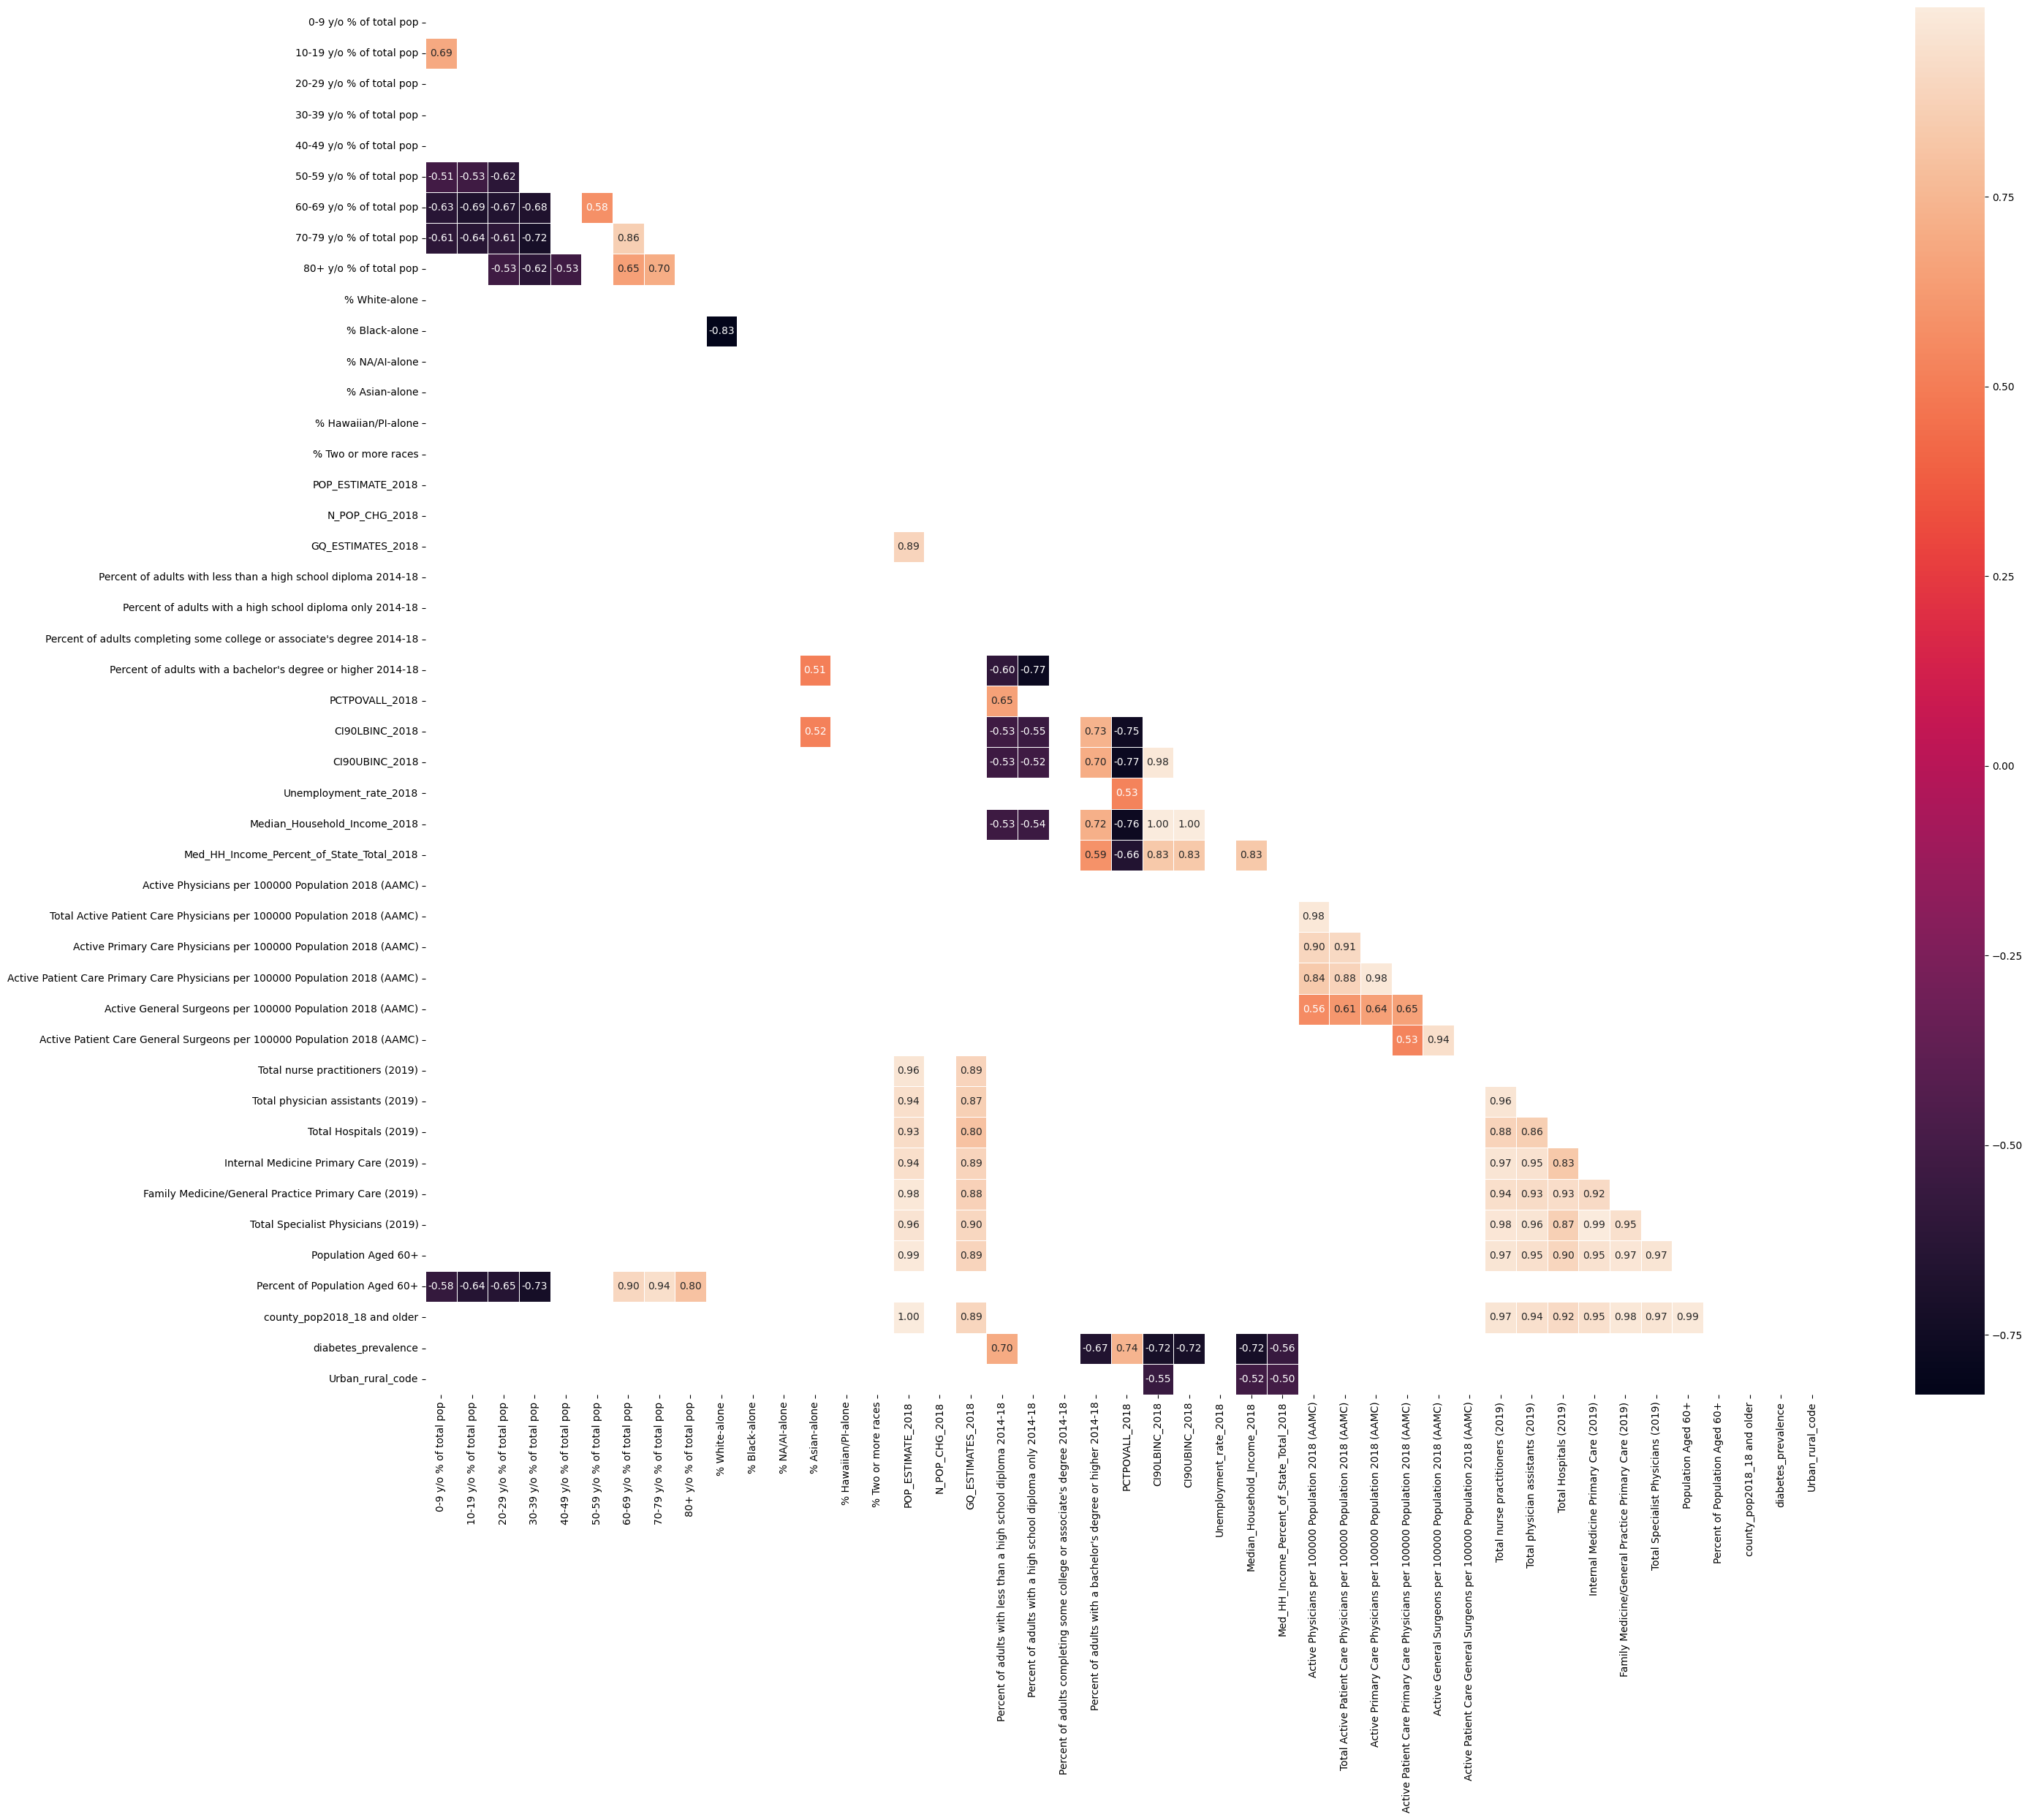

In [150]:
corr = df_diabetes.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.50]
significant_corr
fig, axis = plt.subplots(figsize=(30, 25))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

### Conclusión sobre la matriz de correlación. 


La matriz de correlación permitió identificar grupos de variables altamente relacionadas entre sí, especialmente en los ámbitos de educación, ingresos y recursos sanitarios. 

### Análisis gráfico de mi target. 

>- Diabetes vs. ingresos
>- Diabetes vs. educación
>- Diabetes vs. edad
>- Diabetes vs. atención primaria

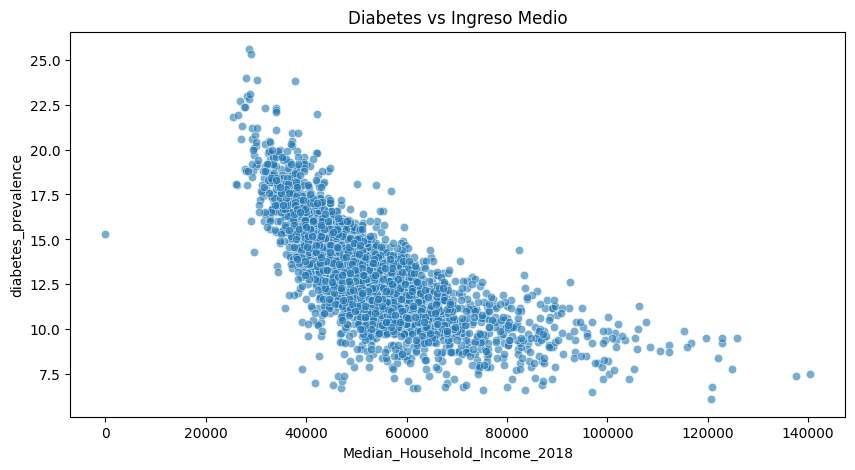

In [151]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Median_Household_Income_2018", y="diabetes_prevalence", data=df_diabetes, alpha=0.6)
plt.title('Diabetes vs Ingreso Medio')
plt.show()


Se observa una relación negativa entre el ingreso medio del hogar y la prevalencia de la diabetes, siendo mayor en condados con menores ingresos.

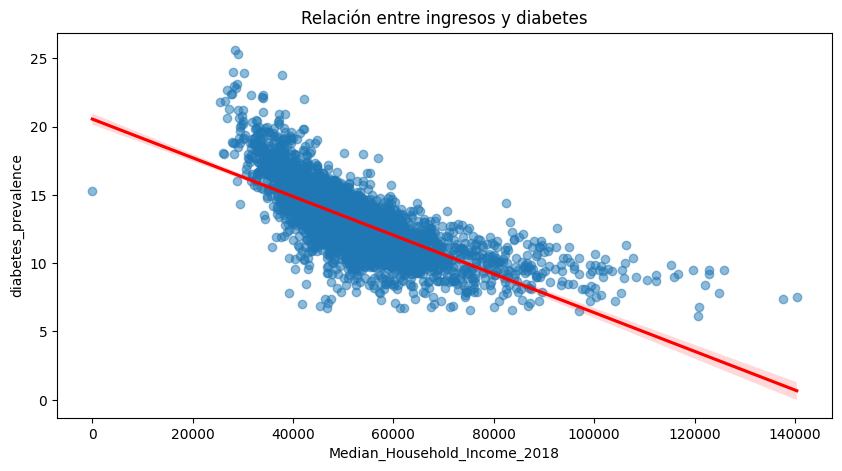

In [152]:
plt.figure(figsize=(10,5))
sns.regplot(x="Median_Household_Income_2018", y="diabetes_prevalence", data=df_diabetes,scatter_kws={'alpha':0.5},line_kws={'color':'red'})
plt.title('Relación entre ingresos y diabetes')
plt.show()


Se observa una relación negativa entre el ingreso medio del hogar y la prevalencia de la diabetes, indicando que a mayores ingresos, menor tasa de diabetes.

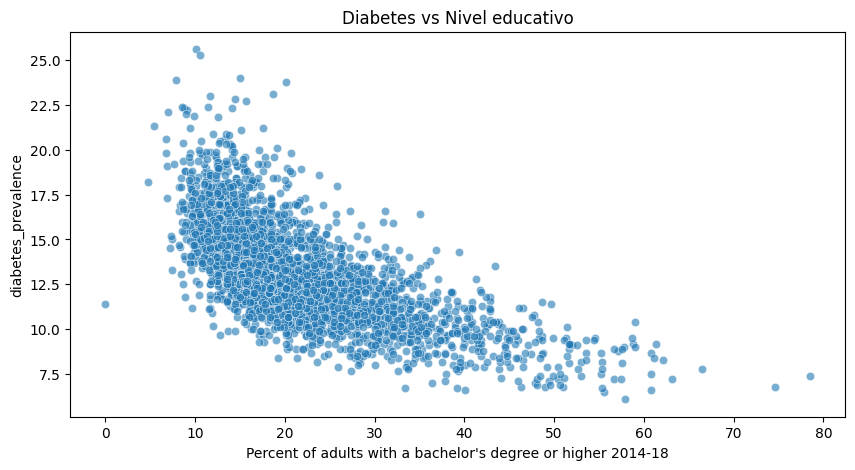

In [153]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Percent of adults with a bachelor's degree or higher 2014-18", y="diabetes_prevalence", data=df_diabetes, alpha=0.6)
plt.title('Diabetes vs Nivel educativo')
plt.show()


Se observa una relación inversa clara entre el nivel educativo y la prevalencia de la diabetes, indicando que a mayor porcentaje de población con estudios superiores, menor tasa de diabetes.

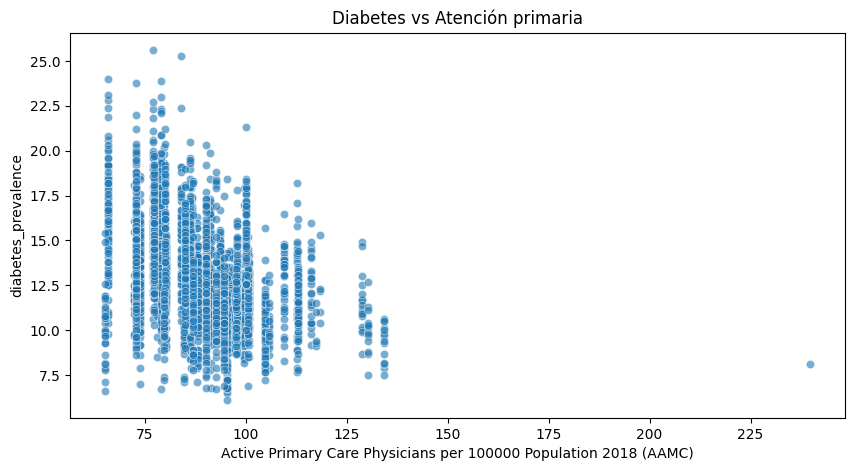

In [154]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Active Primary Care Physicians per 100000 Population 2018 (AAMC)", y="diabetes_prevalence", data=df_diabetes, alpha=0.6)
plt.title('Diabetes vs Atención primaria')
plt.show()


La relación entre la atención primaria y la prevalencia de la diabetes es débil, lo que sugiere que los factores socioeconómicos tienen un mayor impacto en la enfermedad.

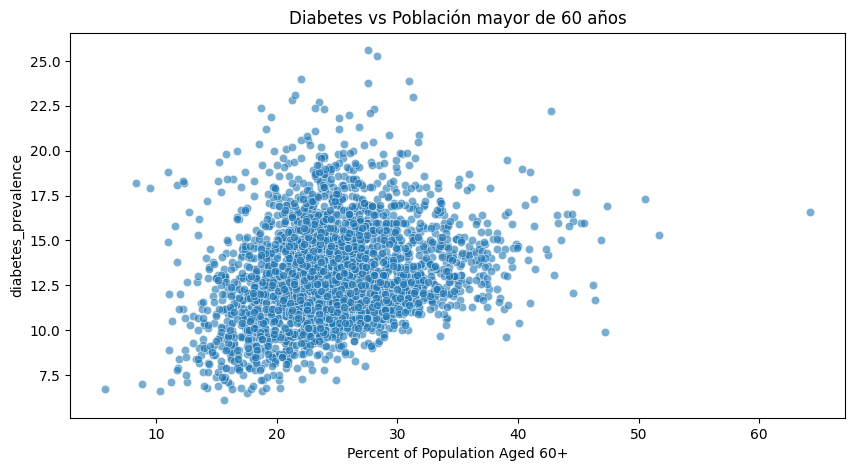

In [155]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Percent of Population Aged 60+", y="diabetes_prevalence", data=df_diabetes, alpha=0.6)
plt.title("Diabetes vs Población mayor de 60 años")
plt.show()


Se observa una relación positiva moderada entre la población mayor de 60 años y la prevalencia de la diabetes, aunque con una dispersión considerable.

## Split.

In [156]:
X = df_diabetes.drop('diabetes_prevalence', axis=1)
y = df_diabetes['diabetes_prevalence']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [157]:
min_max_scaler = MinMaxScaler() 

min_max_features_train = min_max_scaler.fit_transform(X_train)
min_max_features_test = min_max_scaler.transform(X_test)

## Modelado.

In [158]:
model_lineal = LinearRegression()
model_lineal.fit(min_max_features_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [159]:
model_lineal.score(min_max_features_train, y_train)

0.9094783791703103

In [160]:
y_pred = model_lineal.predict(min_max_features_test)
y_pred

array([11.25704217, 12.36231995, 12.438941  , 15.3786298 ,  8.68248296,
       11.79817855, 10.83689857, 14.29793358, 14.26866102, 14.66886139,
        9.93141866, 15.75627565, 14.98784101, 10.01626146, 17.08178222,
        7.61728239, 14.26814103, 13.36879039, 12.06677079, 15.08500218,
       12.80728543, 11.72425926, 11.09531927, 12.77707851, 13.15287554,
       13.15878654, 12.29042029, 16.31886303, 11.74615264,  9.54678416,
       18.05211747, 16.47333109, 12.12800264, 10.370013  , 13.47584903,
       10.29311728, 12.58975768, 12.75880408, 13.17469406, 15.6236434 ,
       12.32206905, 12.12693679,  9.53755677, 12.18275273, 15.81867826,
       11.2851665 , 15.78136635, 10.17831671,  9.57378685, 15.82876635,
       12.09740341, 16.08509278,  9.390113  , 12.16012585, 15.4650594 ,
       10.20557642, 14.35007477, 13.50624943, 11.10253847, 17.15733802,
       15.13385916, 10.93869007, 17.83276081, 10.34347415, 12.16896534,
       21.7657373 , 17.8724916 , 12.91482449, 12.36436939, 14.69

In [161]:
metrics = {'MSE': mean_squared_error(y_test, y_pred),'RMSE': root_mean_squared_error(y_test, y_pred),'MAPE': mean_absolute_percentage_error(y_test, y_pred),'R^2': r2_score(y_test, y_pred), }

metrics

{'MSE': 0.7671525534678344,
 'RMSE': 0.8758724527394581,
 'MAPE': 0.051120273568794616,
 'R^2': 0.893502668984211}

### Conclusión sobre resultados del modelo. 

El modelo de regresión lineal muestra un buen rendimiento, con un R² de 0.89 y un error medio bajo. Esto indica que las variables sociodemográficas seleccionadas explican gran parte de la variación en la prevalencia de la diabetes, destacando la importancia de los factores sociales en la salud de la población.

In [162]:
with open('/workspaces/Antonio27M-machine-learning/models/modelo-lineal-proyect03.pkl', 'wb') as file:
    pickle.dump(model_lineal, file)

In [163]:
model_random = RandomForestRegressor(random_state=18)
model_random.fit(min_max_features_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [164]:
model_random.score(min_max_features_train, y_train)

0.9851054694513539

In [165]:
y_pred_random = model_random.predict(min_max_features_test)
y_pred_random

array([11.344, 11.818, 11.702, 14.836,  9.236, 11.656, 10.291, 14.852,
       14.967, 14.38 , 10.651, 16.182, 14.759, 11.03 , 17.704,  8.772,
       14.308, 13.371, 11.056, 14.756, 12.772, 11.923, 11.218, 13.489,
       12.988, 13.75 , 11.877, 15.953, 12.193,  9.848, 17.254, 16.085,
       11.961, 10.067, 13.31 , 10.641, 12.695, 12.676, 13.315, 15.46 ,
       12.133, 12.59 ,  9.885, 12.615, 16.035, 11.285, 15.337, 10.137,
       10.226, 15.502, 12.135, 16.704,  9.603, 13.033, 15.279,  9.989,
       14.743, 12.584, 11.271, 16.542, 14.424, 10.957, 17.296,  9.825,
       12.216, 22.539, 16.998, 12.925, 12.094, 14.25 , 14.873, 15.613,
       16.454, 19.084, 13.035, 10.814, 15.094, 14.601, 11.105, 12.812,
       12.912, 11.949,  9.484, 14.644, 12.624, 12.755, 15.481, 13.528,
       10.386, 13.111, 15.067, 11.829, 12.358, 11.872, 12.353,  7.899,
       12.119, 13.907, 16.009, 15.464, 10.364, 11.877, 11.862,  9.247,
       10.696, 12.389, 14.469, 14.761, 11.051, 18.298, 14.852, 13.635,
      

In [166]:
metrics = {'MSE': mean_squared_error(y_test, y_pred_random),'RMSE': root_mean_squared_error(y_test, y_pred_random),'MAPE': mean_absolute_percentage_error(y_test, y_pred_random),'R^2': r2_score(y_test, y_pred_random), }

metrics

{'MSE': 0.7237435780254781,
 'RMSE': 0.8507312019818469,
 'MAPE': 0.050833246436840306,
 'R^2': 0.8995287716229149}

### Conclusión sobre resultados del modelo. 

El modelo Random Forest presenta un rendimiento ligeramente superior al de la regresión lineal, con un R² cercano a 0.90 y un error bajo. Esto confirma la solidez de los resultados obtenidos y refuerza la relación entre los factores sociodemográficos y la prevalencia de la diabetes.

In [167]:
with open('/workspaces/Antonio27M-machine-learning/models/modelo-random-proyect03.pkl', 'wb') as file:
    pickle.dump(model_random, file)

### Conclusión final. 

En este proyecto se analizó la relación entre la prevalencia de la diabetes y diferentes factores sociodemográficos y de recursos sanitarios en los condados de Estados Unidos. A partir del análisis exploratorio y de los modelos de regresión aplicados, se observó que variables como el nivel de ingresos, el nivel educativo y la edad de la población están claramente relacionadas con la prevalencia de la diabetes.

Los resultados obtenidos muestran que los factores sociodemográficos explican mejor la presencia de la diabetes que la disponibilidad de recursos sanitarios. Aunque el acceso a servicios de salud es importante, por sí solo no parece ser el factor principal que determina la prevalencia de esta enfermedad.

En conjunto, el estudio pone de manifiesto la importancia de los determinantes sociales en la salud y sugiere que las estrategias de prevención de la diabetes deberían considerar no solo el sistema sanitario, sino también las condiciones sociales y económicas de la población.